In [41]:
import sys
sys.path.insert(1, '../../../Utils/')
from classes_unet import *
from sklearn.model_selection import KFold

number_of_the_seed = 2020

random.seed(number_of_the_seed)
set_seed(number_of_the_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [42]:
path=Path('../../../../Datasets/Processed/dataset/')
path_train=path/'train_def'
path_model=Path('../models')

In [43]:
transforms=Compose([HorizontalFlip(p=0.5),Rotate(p=0.40,limit=10)],p=1)
transformPipeline=SegmentationAlbumentationsTransform(transforms)

In [44]:
img = PILImage.create(path_train/'Blast_PCRM_1201754 D5.BMP')
img = transform_image(img)

In [45]:
codes = np.array(['Background','ZP', 'TE', 'ICM'])

In [46]:
bs = 2
callbacks = [EarlyStoppingCallback(patience=3),SaveModelCallback(fname='model'),ReduceLROnPlateau(patience=3)]
opt = ranger

In [47]:
get_y_fn = lambda x: Path(str(x).replace("train_def","GT_Mask"))

In [8]:
def datablock(indx_valid):
    return DataBlock(blocks=(ImageBlock, MaskBlock(codes)),
              get_items=get_files,
              get_y=get_y_fn,
              splitter=IndexSplitter(indx_valid),
              item_tfms=[Resize((480,480)), TargetMaskConvertTransform(), transformPipeline],
              batch_tfms=Normalize.from_stats(*imagenet_stats))

In [9]:
wd = [1e-1,1e-2, 1e-3, 1e-4]

In [10]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.989781,1.148944,0.735756,0.678638,0.601868,0.637411,0.650850,00:28
1,0.516949,0.714026,0.871806,0.865801,0.836405,0.841481,0.850544,00:28
2,0.319704,0.386075,0.878648,0.914129,0.912135,0.899246,0.904516,00:27
3,0.246202,0.263128,0.813791,0.928460,0.920680,0.908097,0.905907,00:26
4,0.213920,0.249803,0.858021,0.916646,0.931709,0.910667,0.911935,00:26
5,0.193285,0.214865,0.906288,0.920650,0.928330,0.917716,0.920096,00:26
6,0.183906,0.211815,0.857529,0.920149,0.925295,0.930804,0.917288,00:28
7,0.162540,0.204972,0.908776,0.923180,0.928883,0.918782,0.921600,00:27
8,0.143004,0.214577,0.908808,0.916408,0.921831,0.917843,0.917383,00:27
9,0.131251,0.207013,0.876050,0.928535,0.936193,0.920031,0.921582,00:28


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.080224,0.190505,0.911575,0.935317,0.940682,0.932956,0.933143,00:54
1,0.079249,0.207111,0.905394,0.936592,0.936549,0.929195,0.930375,00:57
2,0.089015,0.240371,0.859334,0.920603,0.940089,0.913721,0.916650,00:59
3,0.103515,0.216956,0.908545,0.923467,0.926524,0.920523,0.921391,00:55
4,0.103787,0.248366,0.822579,0.920758,0.939677,0.912490,0.911721,00:54
5,0.104762,0.246513,0.850869,0.929076,0.931153,0.912777,0.914928,00:56
6,0.097898,0.211334,0.878082,0.926835,0.941513,0.928971,0.925828,00:59
7,0.094226,0.214571,0.840570,0.926483,0.950077,0.922724,0.921651,00:55
8,0.096302,0.210707,0.874024,0.924271,0.934675,0.929068,0.922756,00:54
9,0.092410,0.224097,0.864621,0.920154,0.944732,0.920730,0.920443,00:56


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.055430,0.216031,0.906188,0.936903,0.943661,0.934239,0.934182,00:54
1,0.057074,0.222269,0.889626,0.938570,0.944336,0.931987,0.932111,00:54
2,0.056238,0.215639,0.906069,0.939012,0.943696,0.935268,0.935050,00:58
3,0.053159,0.214170,0.904423,0.941009,0.942667,0.935050,0.935034,00:56
4,0.049356,0.213833,0.905320,0.940054,0.943457,0.935490,0.935253,00:55


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.959138,1.122389,0.814435,0.734340,0.701093,0.705124,0.726413,00:59
1,0.502308,0.728796,0.859518,0.853994,0.849722,0.839679,0.849911,00:56
2,0.314339,0.399375,0.834349,0.898501,0.917606,0.891184,0.894440,00:56
3,0.250321,0.264455,0.808933,0.913459,0.926049,0.917333,0.906075,00:56
4,0.221799,0.302890,0.718287,0.893210,0.923374,0.899202,0.882926,01:01
5,0.188229,0.248467,0.861503,0.919334,0.920907,0.915303,0.911859,00:57
6,0.167907,0.318585,0.750561,0.898089,0.925042,0.911647,0.892197,00:58
7,0.157072,0.236155,0.884744,0.921124,0.920695,0.916268,0.915302,00:55
8,0.142055,0.234202,0.860986,0.925012,0.927294,0.926307,0.918472,00:59
9,0.132396,0.235171,0.849936,0.923909,0.934496,0.925009,0.918685,00:56


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.072302,0.245882,0.881445,0.932176,0.933663,0.928792,0.925633,00:55
1,0.075265,0.255806,0.870578,0.929642,0.938757,0.928252,0.924958,01:00
2,0.081662,0.280587,0.870114,0.925674,0.934840,0.922063,0.920669,00:56
3,0.094267,0.313991,0.804110,0.913381,0.934031,0.911686,0.905900,00:56
4,0.100882,0.268151,0.866087,0.923947,0.931589,0.927121,0.920524,00:52
5,0.101133,0.291711,0.830967,0.911096,0.931063,0.916998,0.909277,01:00
6,0.101167,0.271262,0.869745,0.913875,0.927736,0.924100,0.916145,00:58
7,0.092731,0.258930,0.836763,0.925153,0.938574,0.929931,0.920114,00:55
8,0.089519,0.260424,0.860031,0.929088,0.933176,0.925774,0.921122,00:55
9,0.081238,0.264881,0.853964,0.933765,0.939345,0.928361,0.924242,00:58


...

epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.101751,0.192168,0.895570,0.936467,0.939562,0.934238,0.931768,01:01
1,0.104218,0.201040,0.909076,0.930568,0.935495,0.930650,0.929566,01:03
2,0.118729,0.215090,0.874466,0.932512,0.935976,0.933014,0.926747,00:59
3,0.146797,0.365454,0.749814,0.891414,0.899776,0.917809,0.884044,01:00
4,0.152997,0.298155,0.851075,0.901791,0.902378,0.915503,0.899999,01:01
5,0.164218,0.253308,0.877548,0.911635,0.920855,0.905063,0.908227,01:03
6,0.155448,0.219942,0.911737,0.912871,0.925111,0.923022,0.919562,00:57
7,0.136150,0.238478,0.864918,0.918988,0.915584,0.928529,0.914126,00:57
8,0.134823,0.346794,0.790130,0.907733,0.921485,0.922996,0.901739,01:01
9,0.130953,0.243121,0.864956,0.921932,0.928220,0.930038,0.919184,01:02


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.079204,0.220521,0.888338,0.935107,0.939091,0.934979,0.930453,01:03
1,0.077897,0.215547,0.900853,0.933471,0.938841,0.935078,0.931575,00:59
2,0.076888,0.225274,0.890337,0.931309,0.938949,0.934551,0.929486,00:59
3,0.074464,0.223983,0.894258,0.932596,0.938393,0.934572,0.930225,01:01
4,0.072325,0.225192,0.892680,0.933482,0.938385,0.934578,0.930263,01:02


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.945814,1.098087,0.827773,0.757734,0.728577,0.740390,0.753617,00:56
1,0.521027,0.668533,0.864091,0.887399,0.871597,0.867129,0.874114,01:01
2,0.328312,0.352711,0.834320,0.907580,0.903582,0.913110,0.899530,01:00
3,0.262298,0.276784,0.827806,0.895716,0.893108,0.921227,0.895224,00:58
4,0.218491,0.314627,0.730564,0.890219,0.918043,0.921757,0.889135,00:58
5,0.195371,0.215063,0.823689,0.911173,0.924378,0.928625,0.910189,01:02
6,0.183225,0.201189,0.869339,0.926696,0.930360,0.930309,0.922808,01:02
7,0.165513,0.211639,0.823880,0.912212,0.935465,0.921935,0.911592,00:59
8,0.153706,0.192904,0.868447,0.929046,0.935233,0.926178,0.922735,00:57
9,0.137492,0.196445,0.858653,0.932984,0.941591,0.923490,0.923484,01:00


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.077733,0.190159,0.897553,0.933994,0.936419,0.932085,0.929648,00:59
1,0.079087,0.204818,0.871171,0.933529,0.934517,0.932069,0.925461,01:02
2,0.086660,0.208794,0.904292,0.931042,0.934169,0.928475,0.928113,00:59
3,0.097656,0.254809,0.857935,0.920279,0.938808,0.915579,0.916747,01:00
4,0.112780,0.237598,0.874664,0.924657,0.913925,0.922296,0.914854,00:58
5,0.107636,0.256474,0.915548,0.908080,0.905536,0.907213,0.908206,00:59
6,0.103765,0.223071,0.852454,0.930058,0.932701,0.919170,0.918173,00:58
7,0.097601,0.208882,0.868102,0.933045,0.933974,0.928229,0.923642,00:59
8,0.087082,0.212855,0.884711,0.929155,0.938023,0.929019,0.926128,00:57
9,0.082670,0.213253,0.870194,0.927692,0.933188,0.935445,0.924883,01:01


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.050376,0.217671,0.899810,0.938284,0.939258,0.934692,0.932603,00:58
1,0.050926,0.219086,0.902998,0.938455,0.938013,0.934525,0.932643,01:00
2,0.049711,0.221758,0.901920,0.937473,0.938722,0.934470,0.932409,00:56
3,0.047968,0.222274,0.901848,0.937261,0.939770,0.934466,0.932665,00:56
4,0.049569,0.222890,0.900225,0.937693,0.940038,0.934548,0.932678,00:56


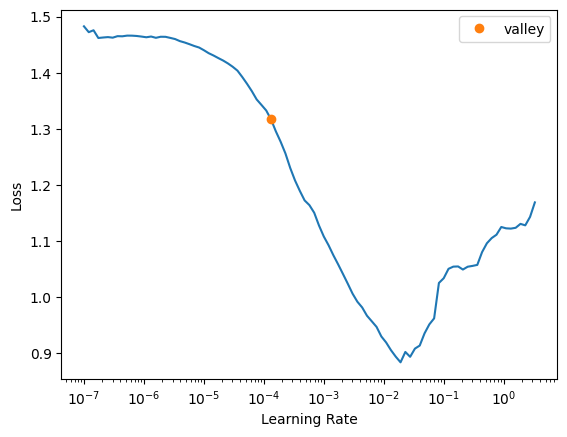

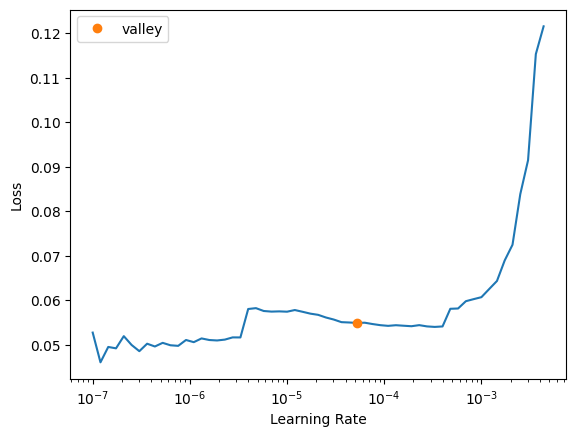

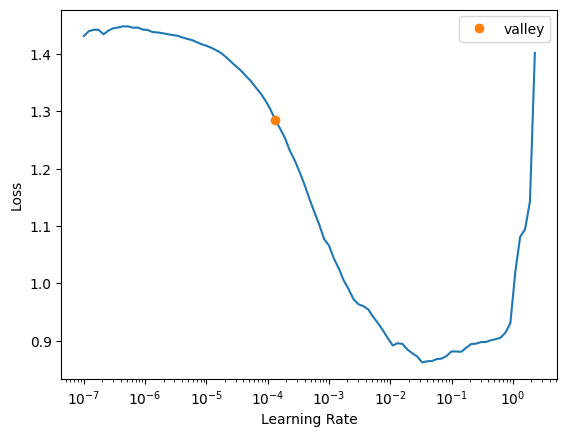

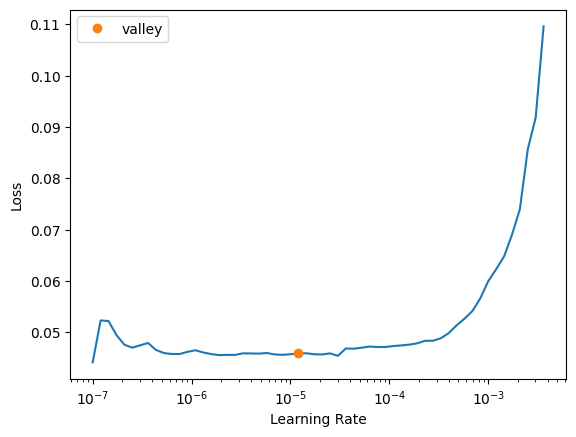

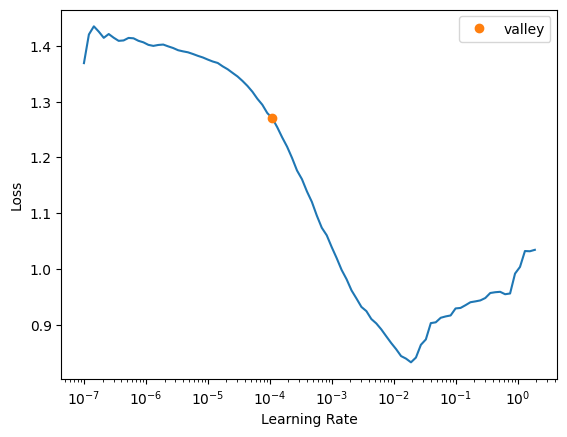

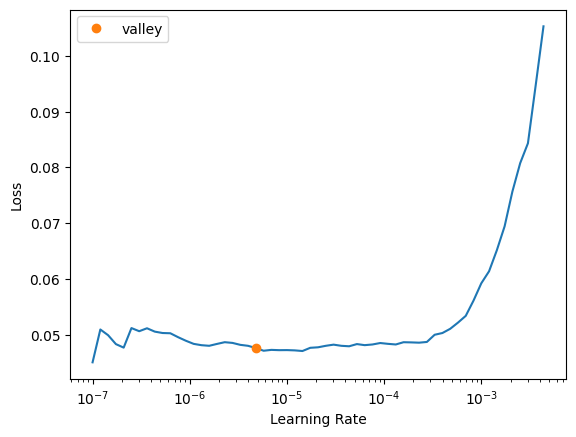

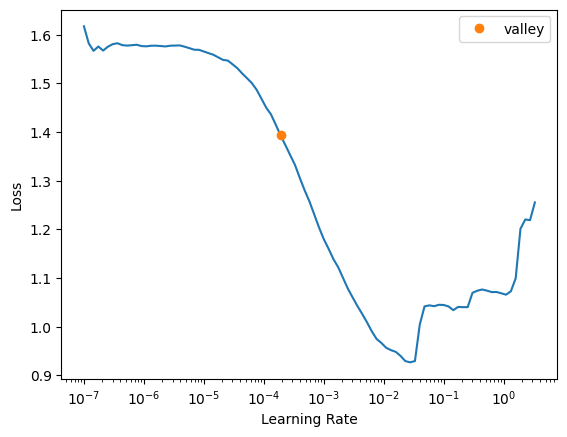

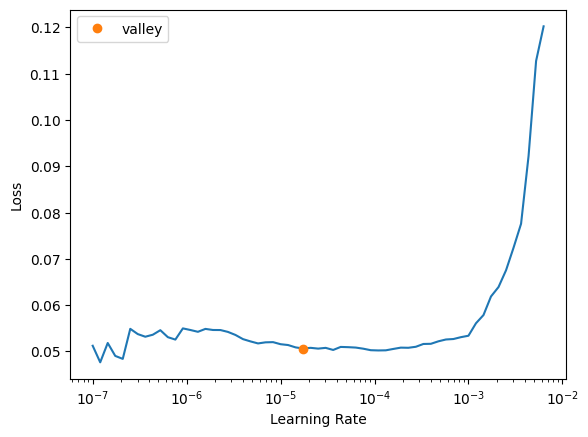

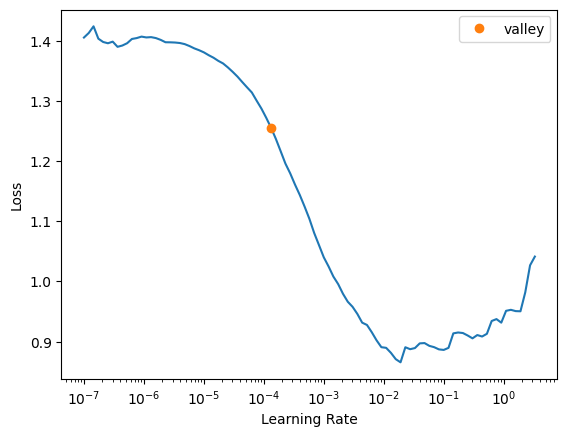

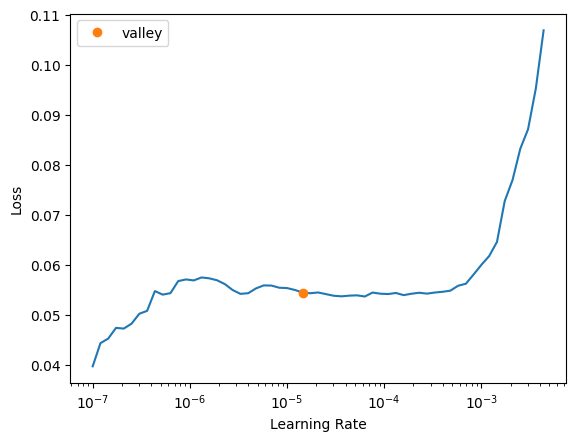

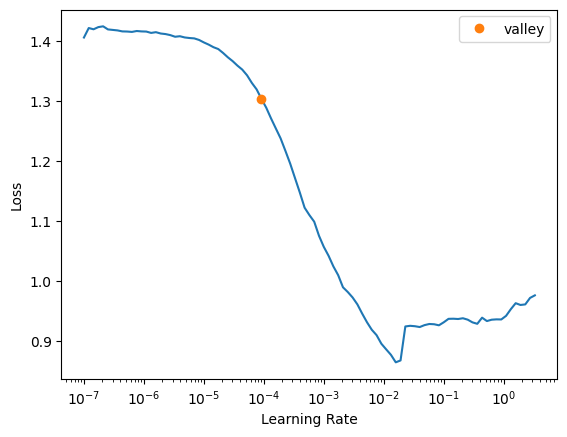

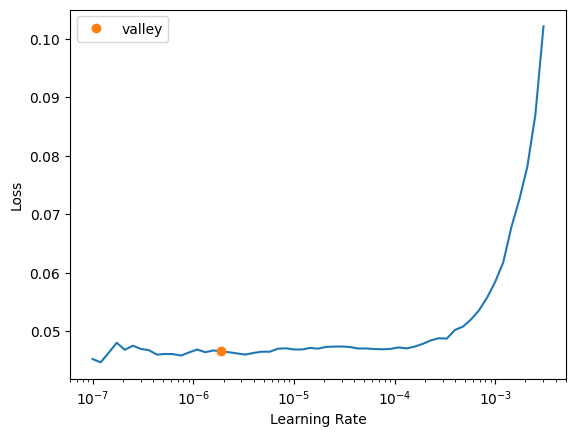

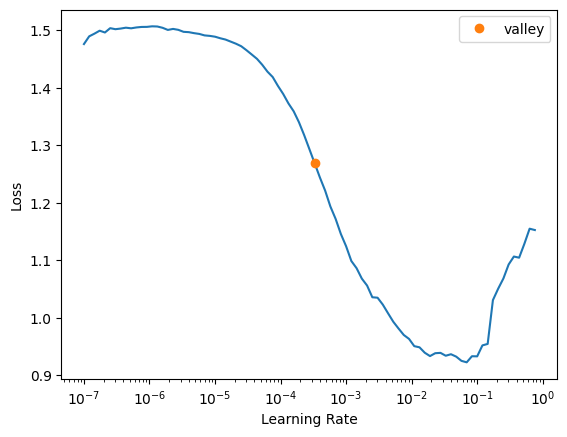

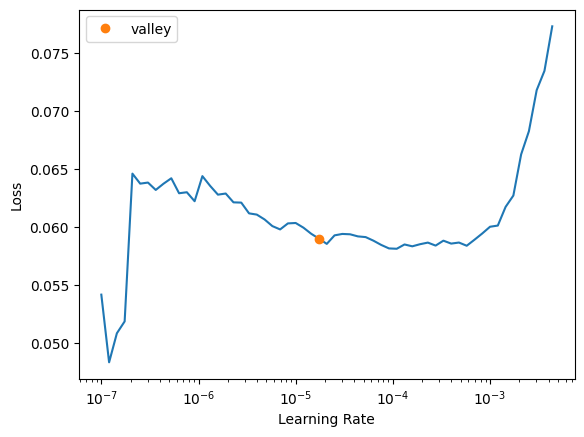

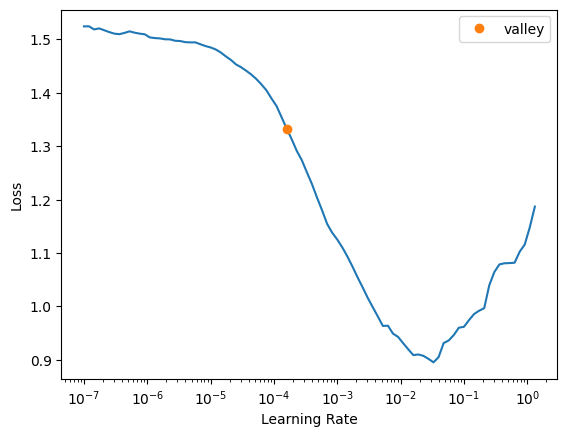

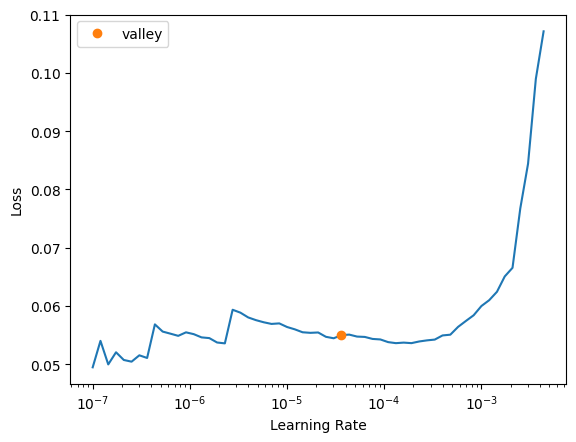

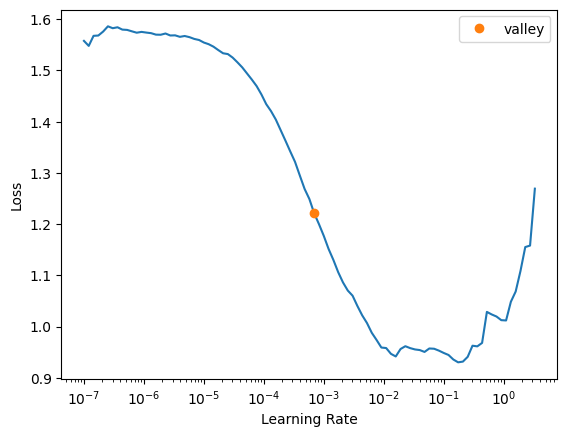

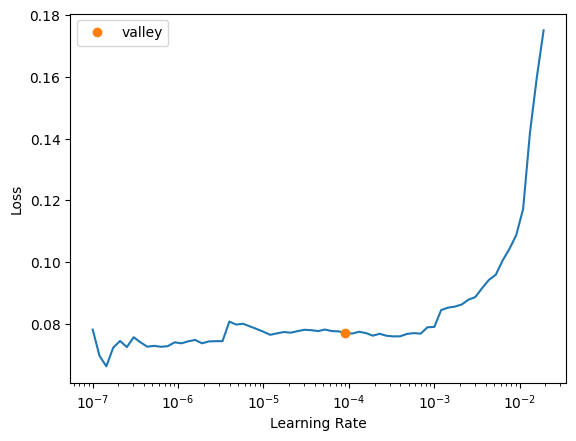

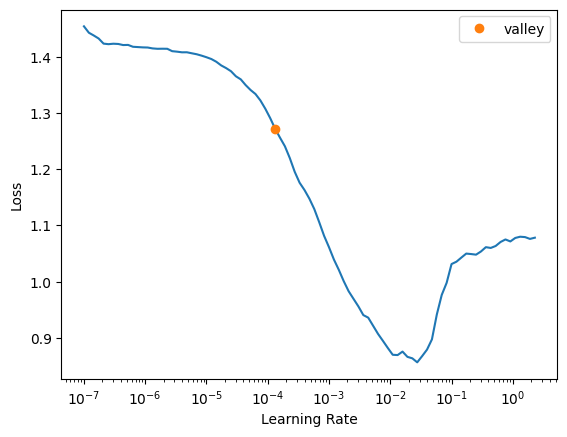

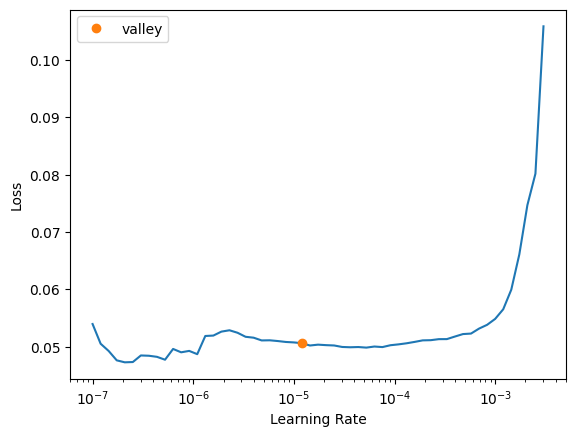

In [11]:
k,j=1,0
for indx_train, indx_valid in kfold.split(get_files(path_train)):
    trainDB = datablock(indx_valid)
    trainDLS = trainDB.dataloaders(path_train,bs=bs)
    learn = get_segmentation_learner(dls=trainDLS, number_classes=4, segmentation_type="Semantic Segmentation",
                                 architecture_name="hrnet", backbone_name="hrnet_w30", 
                                 metrics=[background,zp,te,icm,msa],wd=wd[j],
                                 pretrained=True,normalize=True).to_fp16()
    lr_steep=learn.lr_find()
    learn.fit_one_cycle(20,lr_steep)
    learn.fit_one_cycle(20,lr_steep)
    learn.unfreeze()
    lr_steep=learn.lr_find()
    learn.fit_one_cycle(5,lr_steep)
    aux=learn.model
    aux=aux.cpu()
    img=img.cpu()
    traced_cell=torch.jit.trace(aux, (img))
    traced_cell.save(str(path_model)+f"/kfold_hrnet/{k}.pth")
    k+=1
    j+=1
    if j==4:
        j=0

In [48]:
import sys
sys.path.insert(1, '../Utils/')
from classes_unet import *
from metrics import *

In [49]:
path_test=path/'test_def'
files=[path_test/f for f in os.listdir(path_test)]
gtruth_zp=[get_mask(f,'ZP',path) for f in files]
gtruth_te=[get_mask(f,'TE',path) for f in files]
gtruth_icm=[get_mask(f,'ICM',path) for f in files]

In [11]:
ZP={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
TE={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
ICM={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
for k in range(1,11):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
    file=f"{k}.pth"
    model = torch.jit.load(path_model/"kfold_hrnet"/file)
    model = model.cpu()
    preds=[prediccion(f,model) for f in files]
    preds_zp=[255*(p==75).astype('uint8') for p in preds]  
    preds_te=[255*(p==255).astype('uint8') for p in preds]
    preds_icm=[255*(p==150).astype('uint8') for p in preds]  
    metrics_zp=summary_metrics(gtruth_zp,preds_zp)
    for keys in ZP:
        ZP[keys].append(metrics_zp[keys])
    metrics_te=summary_metrics(gtruth_te,preds_te)
    for keys in TE:
        TE[keys].append(metrics_te[keys])
    metrics_icm=summary_metrics(gtruth_icm,preds_icm)
    for keys in ICM:
        ICM[keys].append(metrics_icm[keys])

In [12]:
def r(n):
    return(round(n,4))

In [23]:
for k in ZP:
    print(k + ': ' +str(ICM[k][6]))

accuracy: 0.9818359663232432
precision: 0.9042617809335429
recall: 0.8740198994392945
specificity: 0.9916284131574675
jaccard: 0.7966214322089371
dice: 0.8797755073041557


In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
file=f"6.pth"
model = torch.jit.load(path_model/"kfold_hrnet"/file)
model = model.cpu()
preds=[prediccion(f,model) for f in files]

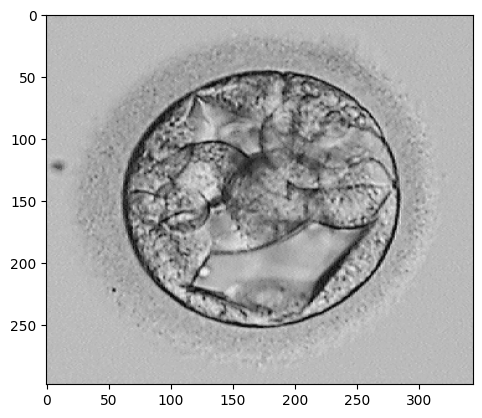

In [62]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

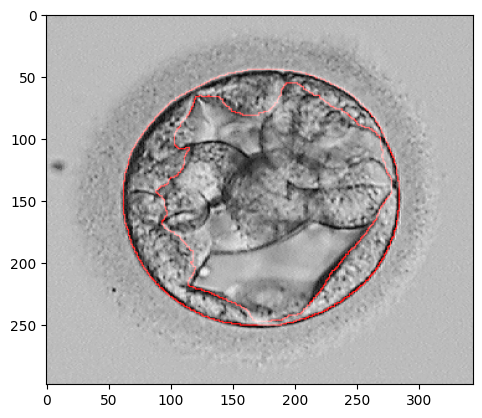

In [55]:
TE=255*(preds[0]==255).astype('uint8')
TE=cv2.dilate(TE, np.ones((3,3)))-TE
TE=cv2.cvtColor(TE,cv2.COLOR_GRAY2RGB)
TE[:,:,1]=0
TE[:,:,2]=0
plt.imshow(cv2.addWeighted(img, 1, TE, 1, 1))

In [63]:
TE=255*(preds[0]==255).astype('uint8')
TE=cv2.dilate(TE, np.ones((3,3)))-TE
img[TE==255]=0
img[:,:,0][TE==255]=255

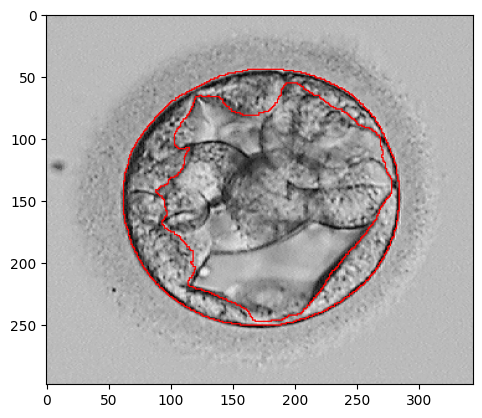

In [68]:
plt.imshow(img)

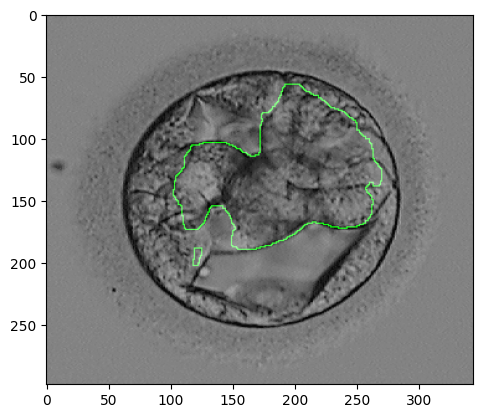

In [28]:
ICM=255*(preds[0]==150).astype('uint8')
ICM=cv2.erode(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM
ICM=cv2.cvtColor(ICM,cv2.COLOR_GRAY2RGB)
ICM[:,:,0]=0
ICM[:,:,2]=0
plt.imshow(cv2.addWeighted(img, 0.7, ICM, 1, 0.0))

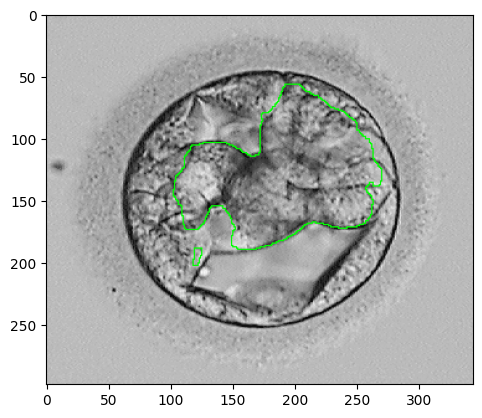

In [70]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

ICM=255*(preds[0]==150).astype('uint8')
ICM=cv2.erode(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM

img[ICM==255]=0
img[:,:,1][ICM==255]=255
plt.imshow(img)

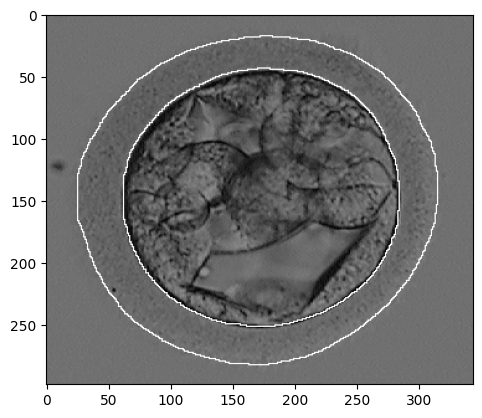

In [29]:
ZP=255*(preds[0]==75).astype('uint8')
ZP=cv2.erode(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP
ZP=cv2.cvtColor(ZP,cv2.COLOR_GRAY2RGB)
plt.imshow(cv2.addWeighted(img, 0.6, ZP, 1, 0))

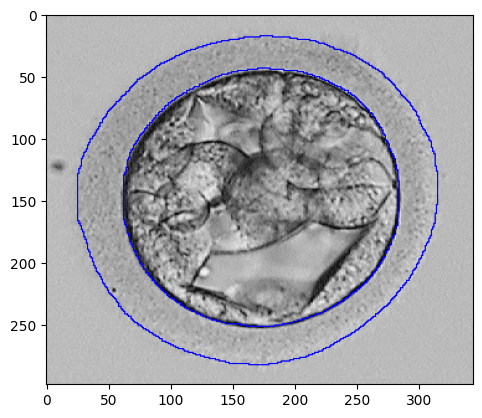

In [78]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

ZP=255*(preds[0]==75).astype('uint8')
ZP=cv2.erode(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP

img[ZP==255]=0
img[:,:,2][ZP==255]=255
plt.imshow(img)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
file=f"6.pth"
model = torch.jit.load(path_model/"kfold_hrnet"/file)
model = model.cpu()

In [3]:
path=Path('../../../../Datasets/Processed/Clara/embriones/')
files=[path/f for f in os.listdir(path)]

In [5]:
preds=[prediccion(f,model) for f in files]

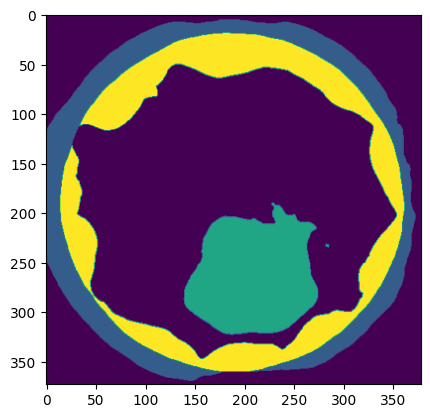

In [6]:
plt.imshow(preds[0])

In [7]:
def pred_te(img,predss):
    TE=255*(predss==255).astype('uint8')
    TE=cv2.dilate(TE, np.ones((3,3)))-TE
    TE=cv2.cvtColor(TE,cv2.COLOR_GRAY2RGB)
    TE[:,:,1]=0
    TE[:,:,0]=0
    return(cv2.addWeighted(img, 0.7, TE, 1, 0.0))

In [8]:
def pred_icm(img,predss):
    ICM=255*(predss==150).astype('uint8')
    ICM=cv2.erode(ICM, np.ones((3,3)))
    ICM=cv2.dilate(ICM, np.ones((3,3)))
    ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM
    ICM=cv2.cvtColor(ICM,cv2.COLOR_GRAY2RGB)
    ICM[:,:,0]=0
    ICM[:,:,2]=0
    return(cv2.addWeighted(img, 0.7, ICM, 1, 0.0))

In [9]:
def pred_zp(img,predss):
    ZP=255*(predss==75).astype('uint8')
    ZP=cv2.erode(ZP, np.ones((3,3)))
    ZP=cv2.dilate(ZP, np.ones((3,3)))
    ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP
    ZP=cv2.cvtColor(ZP,cv2.COLOR_GRAY2RGB)
    return(cv2.addWeighted(img, 0.6, ZP, 1, 0))

In [11]:
i=0
for f in files:
    img=cv2.imread(str(f))
    te=pred_te(img,preds[i])
    icm=pred_icm(img,preds[i])
    zp=pred_zp(img,preds[i])
    cv2.imwrite(f.stem+'_te.png',te)
    cv2.imwrite(f.stem+'_icm.png',icm)
    cv2.imwrite(f.stem+'_zp.png',zp)
    i+=1
    

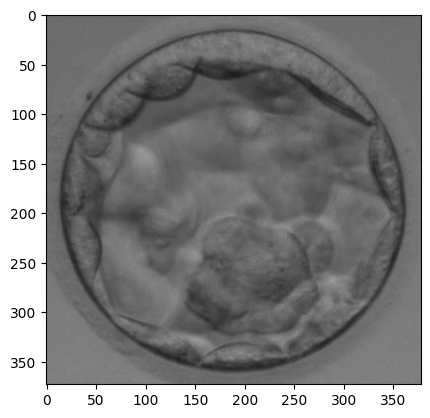

In [34]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

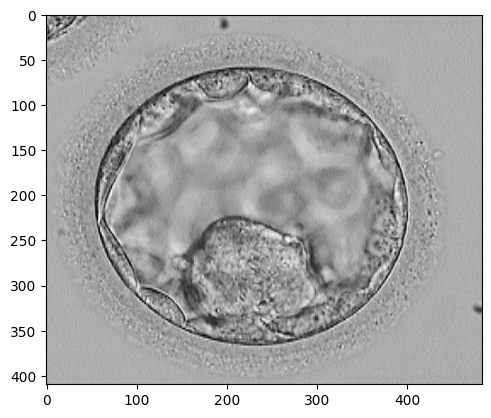

In [14]:
img=cv2.imread(str(files[7]))
plt.imshow(img)

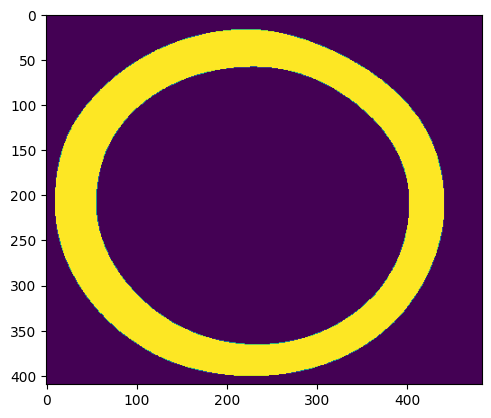

In [17]:
plt.imshow(gtruth_zp[7])

In [36]:
ZP=gtruth_zp[7]
ZP=cv2.cvtColor(ZP,cv2.COLOR_GRAY2RGB)


In [37]:
TE=gtruth_te[7]
TE=cv2.cvtColor(TE,cv2.COLOR_GRAY2RGB)
TE[:,:,1]=0
TE[:,:,2]=0


In [38]:
ICM=gtruth_icm[7]
ICM=cv2.cvtColor(ICM,cv2.COLOR_GRAY2RGB)
ICM[:,:,0]=0
ICM[:,:,2]=0

In [39]:
all_=ZP+TE+ICM

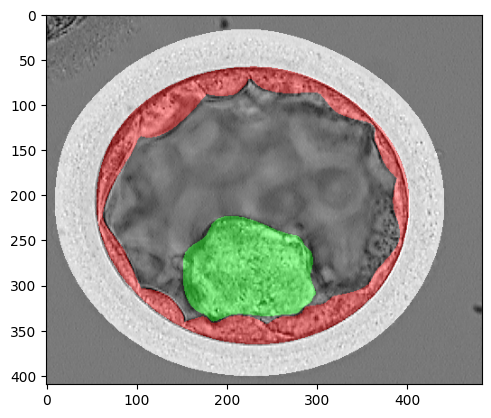

In [40]:
plt.imshow(cv2.addWeighted(img, 0.7, all_, 0.4, 0))